In [6]:
# ===== INPUT: Define date and time to search for =====
search_date = "20260128"  # Format: YYYYMMDD
search_time = "021808"    # Format: HHMMSS

Found 1 files:

rfd4 files:

rfd10 files:

rfd11 files:
  20260128_021808_rfd11tbs1.csv
20260128_021808_rfd11tbs1.csv: Edge time = 6.195 µs


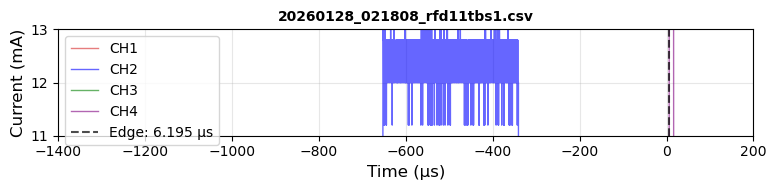

In [13]:
# Plot electrode traces with pre-calculated time shifts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Data folder path
data_folder = Path("/Users/xylu/Desktop/Data/electrode_local")

# Automatically find files matching the date and time
search_pattern = f"{search_date}_{search_time}_*.csv"
all_files = sorted(data_folder.glob(search_pattern))

# Group files by RFD type and sort within groups
rfd4_files = sorted([f for f in all_files if 'rfd4' in f.name])
rfd10_files = sorted([f for f in all_files if 'rfd10' in f.name])
rfd11_files = sorted([f for f in all_files if 'rfd11' in f.name])

# Combine in order: rfd4, rfd10, rfd11
file_paths = rfd4_files + rfd10_files + rfd11_files

if not file_paths:
    print(f"No files found matching pattern: {search_pattern}")
else:
    print(f"Found {len(file_paths)} files:")
    print("\nrfd4 files:")
    for f in rfd4_files:
        print(f"  {f.name}")
    print("\nrfd10 files:")
    for f in rfd10_files:
        print(f"  {f.name}")
    print("\nrfd11 files:")
    for f in rfd11_files:
        print(f"  {f.name}")

# Moving average filter settings
moving_avg_window = 1  # points

# Pre-calculated time shifts for each file type (in µs)
# These shifts align the rising edge to the target times
time_shifts = {
    'rfd4tbs2': 8.707,     # edge -3.050 -> target 5.657
    'rfd10tbs1': 10.320,   # edge -4.625 -> target 5.695
    'rfd11tbs1': -0.205,   # edge 6.400 -> target 6.195
    'rfd11tbs2': -0.205    # edge 6.400 -> target 6.195
}

# Edge detection settings
edge_threshold_ma = 30  # mA - detect rising edge

# Create subplots based on number of files found
num_files = len(file_paths)
if num_files > 0:
    fig, axes = plt.subplots(num_files, 1, figsize=(8, 2 * num_files))
    if num_files == 1:
        axes = [axes]  # Make it iterable for single subplot
else:
    print("No files to plot")
    exit()

# Channel colors
color_map = {'CH1': '#d62728', 'CH2': 'blue', 'CH3': 'green', 'CH4': 'purple'}

# Plot each file
for idx, file_path in enumerate(file_paths):
    
    title_name = os.path.basename(file_path)
    
    # Read all channels
    df = pd.read_csv(file_path, skiprows=4, usecols=['CH1', 'CH2', 'CH3', 'CH4'])
    channels = ['CH1', 'CH2', 'CH3', 'CH4']
    
    # Create time array with base offset
    time_us = np.arange(len(df)) * 75e-9 * 1e6 - 1400
    
    # Extract file identifier (e.g., 'rfd4tbs2' from filename)
    file_stem = file_path.stem  # e.g., '20260128_025331_rfd4tbs2'
    file_id = file_stem.split('_')[-1]  # e.g., 'rfd4tbs2'
    # Apply pre-calculated time shift
    if file_id in time_shifts:
        time_us = time_us + time_shifts[file_id]
    
    # Apply moving average filter to all channels and convert to current (mA)
    smoothed_data = {}
    for ch_name in channels:
        ch_data = df[ch_name].values
        ch_data = pd.Series(ch_data).rolling(window=moving_avg_window, center=True).mean().values
        smoothed_data[ch_name] = ch_data / 10/50 * 1000  # Convert to mA
    
    # Find rising edge (first point above threshold) from CH4
    current_ch4_ma = smoothed_data['CH4']
    above_threshold = current_ch4_ma > edge_threshold_ma
    threshold_indices = np.where(above_threshold)[0]
    edge_time = None
    
    if len(threshold_indices) > 0:
        edge_idx = threshold_indices[0]
        edge_time = time_us[edge_idx]
    
    print(f"{title_name}: Edge time = {edge_time:.3f} µs" if edge_time is not None else f"{title_name}: No edge detected")
    
    # Plot each channel
    for ch_name in channels:
        current_ma = smoothed_data[ch_name]
        axes[idx].plot(time_us, current_ma, color=color_map[ch_name], linewidth=1, 
                      marker=None, markersize=1, alpha=0.6, label=ch_name)
    
    # Add rising edge marker if available
    if edge_time is not None:
        axes[idx].axvline(x=edge_time, color='black', linestyle='--', linewidth=1.5, 
                         alpha=0.7, label=f'Edge: {edge_time:.3f} µs')
    
    axes[idx].set_xlabel('Time (µs)', fontsize=12)
    axes[idx].set_ylabel('Current (mA)', fontsize=12)
    axes[idx].set_title(title_name, fontsize=10, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(labelsize=10)
    axes[idx].set_ylim(11, 13)
    axes[idx].set_xlim(-1400, 200)
    axes[idx].legend(fontsize=10, loc='upper left')

# Hide unused subplots
for idx in range(len(file_paths), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()
